In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the DenseNet-169 model
from model import DepthEstimate
model_densenet = DepthEstimate()
checkpoint_path_densenet = "training_DenseNet_NewLoss/cp.ckpt"
model_densenet.load_weights(checkpoint_path_densenet)

# Load the EfficientNet model
model_efficientnet = DepthEstimate()
checkpoint_path_efficientnet = "training_DN_updLOSS/cp.ckpt"
model_efficientnet.load_weights(checkpoint_path_efficientnet)


Base model loaded DenseNet169

Model created.
Base model loaded DenseNet169

Model created.


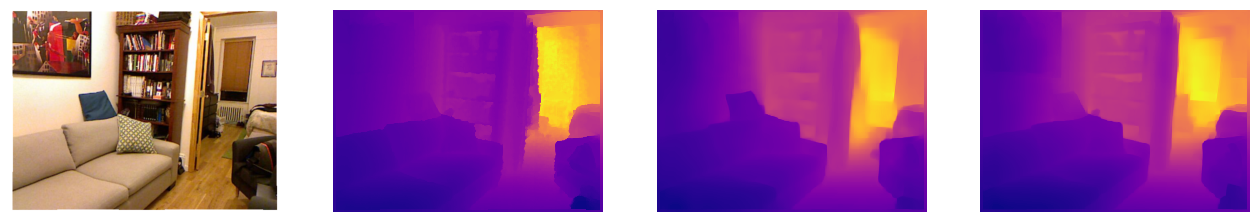

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# Load the image
image_path = '/Users/adeelhafeez/Documents/Depth_estimation/nyu_data/data/nyu2_test/00170_colors.png'
image = tf.image.decode_image(tf.io.read_file(image_path), channels=3)
image = tf.image.convert_image_dtype(image, tf.float32)

# Load the true depth
true_depth_path = '/Users/adeelhafeez/Documents/Depth_estimation/nyu_data/data/nyu2_test/00170_depth.png'

# Read the depth map image using OpenCV (in grayscale)
true_depth = cv2.imread(true_depth_path, cv2.IMREAD_UNCHANGED)

if true_depth is not None:
    true_depth = true_depth.astype('float32')  # Convert to float32 for consistency

    # Make depth predictions with both models
    image_batch = tf.expand_dims(image, 0)
    predicted_depth_densenet = model_densenet(image_batch)
    predicted_depth_efficientnet = model_efficientnet(image_batch)

    # Invert the predicted depth by taking the reciprocal for both models
    inverted_predicted_depth_densenet = 1.0 / predicted_depth_densenet
    inverted_predicted_depth_efficientnet = 1.0 / predicted_depth_efficientnet

    # Squeeze the true depth image to remove the singleton dimension
    true_depth = tf.squeeze(true_depth)

    # Arrange the output as 1 row and 4 columns
    plt.figure(figsize=(16, 4))

    plt.subplot(141)
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(142)
    plt.imshow(true_depth, cmap='plasma', interpolation='nearest')
    plt.axis('off')

    plt.subplot(143)
    plt.imshow(inverted_predicted_depth_densenet[0, ..., 0], cmap='plasma', interpolation='nearest')
    plt.axis('off')

    plt.subplot(144)
    plt.imshow(inverted_predicted_depth_efficientnet[0, ..., 0], cmap='plasma', interpolation='nearest')
    plt.axis('off')

    plt.show()
else:
    print("Failed to read the true depth map image.")
